EDA Cleveland

In [20]:
import pandas as pd
from typing import Dict, List, Tuple
import matplotlib.pyplot as plt
import seaborn as sns

Categorical values

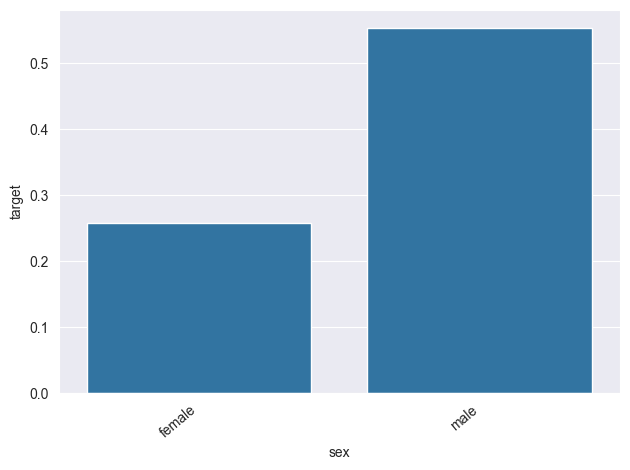

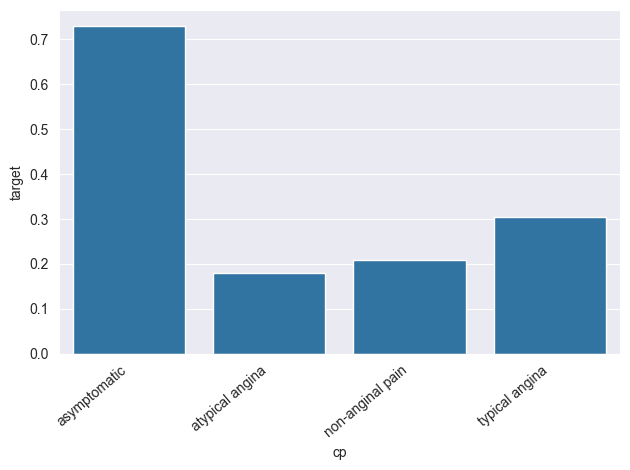

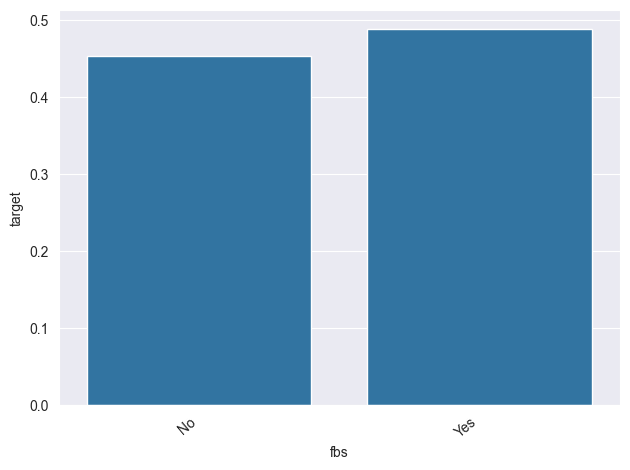

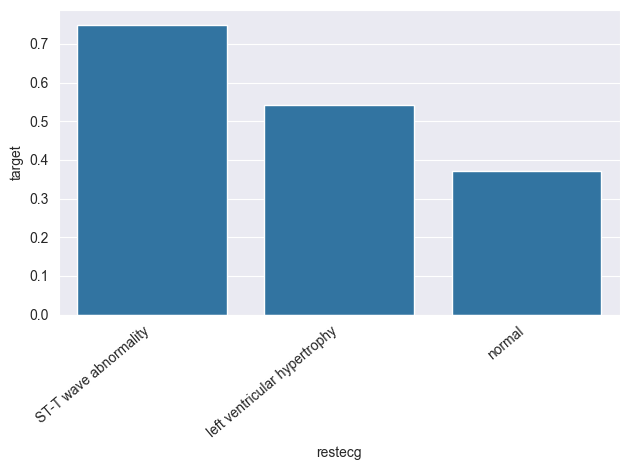

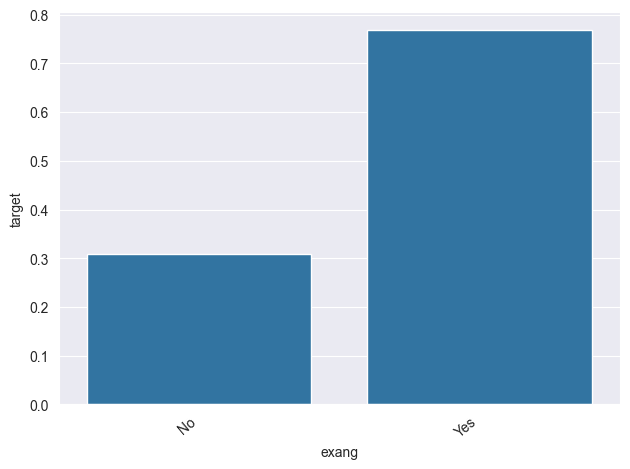

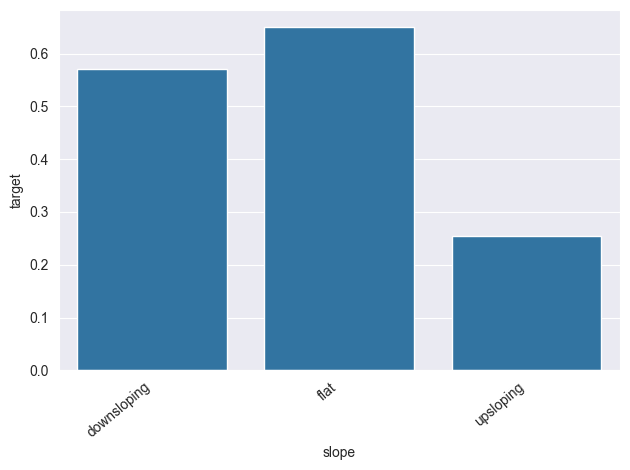

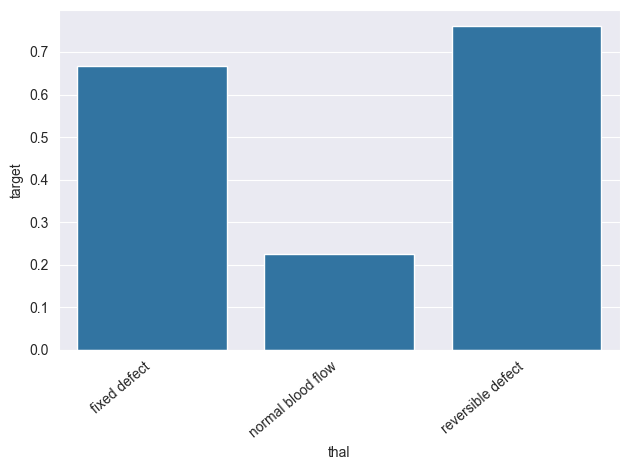

In [21]:
def plot_categorical_data_with_target_rate(df_data: pd.DataFrame, y: str, x: str):
    var = [x, y]
    df_plot = df_data[var].groupby(x).agg("mean").reset_index()
    ax = sns.barplot(x=x, y=y, data=df_plot)
    ax.tick_params(axis="x", labelrotation=40)
    for lab in ax.get_xticklabels():
        lab.set_ha("right")
    plt.tight_layout()
    plt.show()
    plt.close()


df = pd.read_csv(r"../data/processed_cleveland.csv")

def run_categorical_in_loop(df_data: pd.DataFrame, y: str, input_columns: List, ignore_columns: List):
    for col in input_columns:
        if col not in ignore_columns:
            plot_categorical_data_with_target_rate(df, y=y, x=col)


categorical_cols = df.columns[
    df.columns.isin(df._get_numeric_data().columns) == False
]

ignore_categorical = ['target']

run_categorical_in_loop(df, 'target', categorical_cols, ignore_categorical)

Numerical values

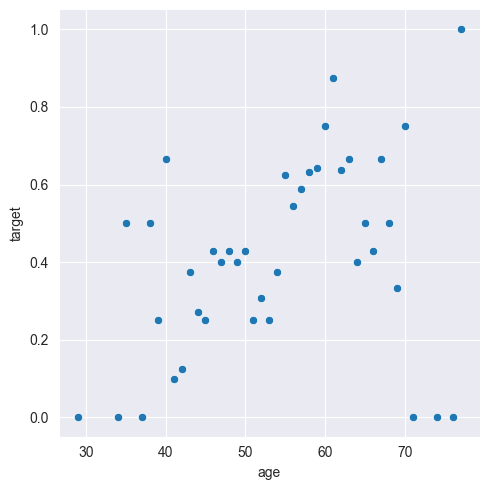

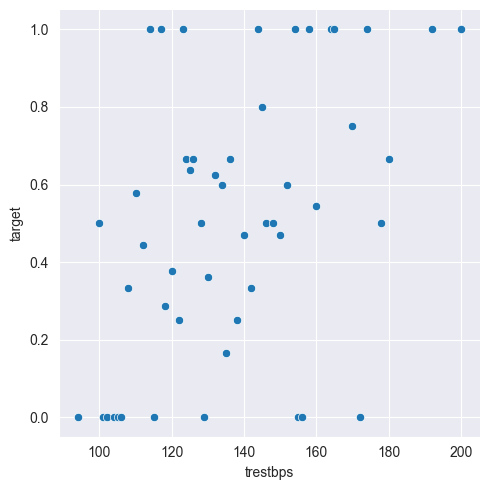

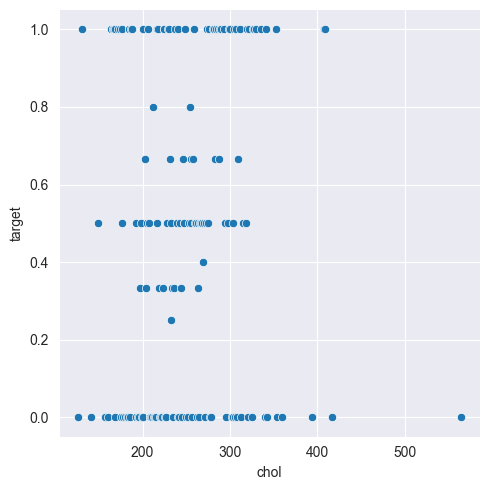

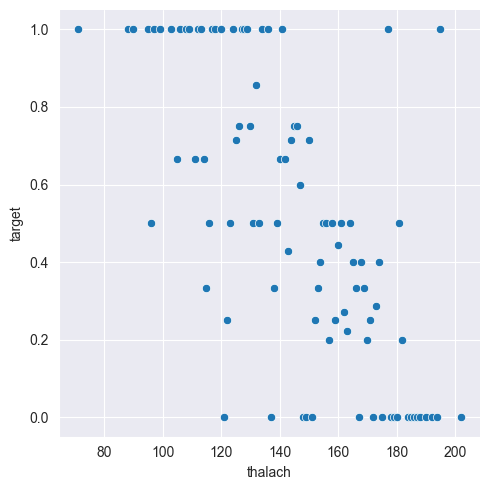

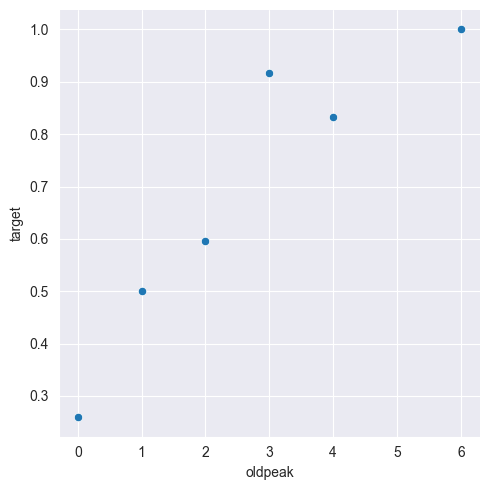

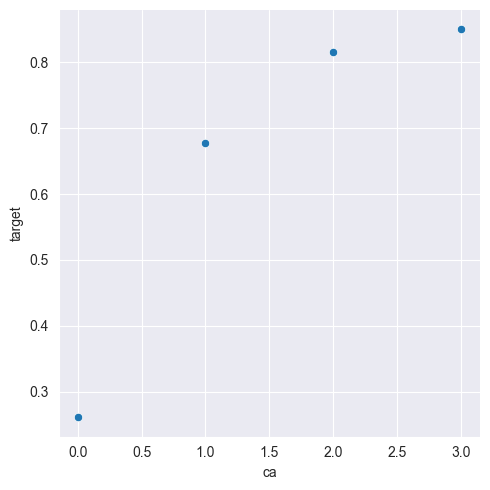

In [22]:
def plot_numeric_data_with_target_rate(df_data: pd.DataFrame, y: str, x: str):
    var = [x, y]
    df_plot = df_data[var].copy()
    df_plot[x] = round(df_plot[x], 0)
    df_plot = df_plot.groupby(x).agg("mean").reset_index()
    ax = sns.relplot(x=x, y=y, data=df_plot)
    plt.tight_layout()
    plt.show()
    plt.close()

def run_numerical_in_loop(df_data: pd.DataFrame, y: str, input_columns: List, ignore_columns: List):
    for col in input_columns:
        if col not in ignore_columns:
            plot_numeric_data_with_target_rate(df, y=y, x=col)

numeric_cols = df.columns[df.columns.isin(df._get_numeric_data().columns) == True]
ignore_list = ['target']
run_numerical_in_loop(df, 'target', numeric_cols, ignore_list)